# 03 — Real two-GPU throughput: converging queue vs the alternatives

**Run on the CUDA host** (`uv sync --extra dev --extra gpu`, then
`uv run jupyter lab`).
This notebook decides whether the project was worth building; keep its
executed outputs committed — they are the evidence. Re-run it top to bottom
on the GPU host after any change to batching, scheduling or the engine.

Four configurations, same inputs, same model:

1. fast GPU alone (TEI-equivalent baseline)
2. both GPUs, static 50/50 item split
3. both GPUs, static split weighted by configured device weights
4. both GPUs, converging queue (embedx as built)

Measurement hygiene, all required: correctness asserted before any timing,
warmup runs discarded, `torch.cuda.synchronize()` on every device around
every timed region, medians over several runs with spread, and an explicit
record of anything else holding VRAM during the run.

In [1]:
import os
import subprocess
import threading
import time

import numpy as np
import torch

print(torch.cuda.get_arch_list())

# --- Environment record: contaminated numbers that look clean are worse ---
# --- than no numbers. If Ollama (or anything) holds VRAM, it shows here. ---
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    print(f"cuda:{i} {torch.cuda.get_device_name(i)}  "
          f"free={free / 2**30:.1f} GiB / total={total / 2**30:.1f} GiB  "
          f"(anything missing from 'free' is held by another process)")
# Read from nvidia-smi, not hand-written. This used to be a prose paragraph
# describing what nvidia-smi had shown on one particular day, which is a
# retyped number by another name: it stayed in the file verbatim across
# re-runs and would have kept asserting a VRAM state that no longer held.
# Same rule as everywhere else here -- if it was not measured in this run, it
# does not get claimed in this run.
def other_vram_users():
    out = subprocess.run(
        ["nvidia-smi", "--query-compute-apps=pid,process_name,used_memory",
         "--format=csv,noheader"],
        capture_output=True, text=True).stdout.strip()
    mine = str(os.getpid())
    rows = [r.strip() for r in out.splitlines()
            if r.strip() and r.split(",")[0].strip() != mine]
    return rows or ["none: no other process held VRAM when this run started"]


OTHER_VRAM_USERS = other_vram_users()
print("other processes holding VRAM as this run starts:")
for row in OTHER_VRAM_USERS:
    print(f"    {row}")
print("(`ollama serve` runs on this host permanently; what matters is whether "
      "it held a MODEL, which the start/end free-VRAM check below settles.)")

# Baseline for the contamination check in the final cell. If anything grabs
# VRAM while the benchmark runs, the numbers above it are suspect and the
# notebook has to say so rather than quietly average it in.
VRAM_FREE_AT_START = {i: torch.cuda.mem_get_info(i)[0]
                      for i in range(torch.cuda.device_count())}

['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
Sun Aug  2 17:49:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.43.02     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 2000 Blac...    Off |   00000000:01:00.0  On |                  Off |
| 30%   34C    P8              7W /   70W |     164MiB /  16311MiB |      0%      Default |
|                                         |                        |               

cuda:0 NVIDIA RTX PRO 2000 Blackwell  free=15.2 GiB / total=15.5 GiB  (anything missing from 'free' is held by another process)
cuda:1 NVIDIA RTX A400  free=3.6 GiB / total=3.7 GiB  (anything missing from 'free' is held by another process)
other processes holding VRAM as this run starts:
    228468, /home/luxor/Programming/embedx/.venv/bin/python, 122 MiB
    228468, /home/luxor/Programming/embedx/.venv/bin/python, 44 MiB
(`ollama serve` runs on this host permanently; what matters is whether it held a MODEL, which the start/end free-VRAM check below settles.)


In [2]:
from embedx.backend.hf import HFBackend, TokenLengthCache
from embedx.config import Dtype, Pooling, Settings
from embedx.engine import Engine, make_batches
from embedx.gpu.budgets import device_budgets
from embedx.gpu.discovery import discover_devices, rank_devices

# Model handling is per-model rather than server-wide since task 15: Settings
# no longer carries model_id, pooling, dtype or max_seq_len, because one
# server serves many checkpoints and a request names the one it wants. Here
# there is no request, so they are plain constants handed straight to
# HFBackend -- and named, so the evidence file can record what was measured
# instead of inferring it from config that no longer holds it.
MODEL = "sentence-transformers/all-MiniLM-L6-v2"
POOLING = Pooling.MEAN
DTYPE = Dtype.AUTO  # resolves to bfloat16 on both cards here
MAX_SEQ_LEN = 512

settings = Settings(max_batch_tokens=16384)

infos = discover_devices(settings.devices)
ranked = rank_devices(infos, settings.device_weights)
budgets = device_budgets(ranked, settings.max_batch_tokens, settings.device_batch_tokens)
assert len(ranked) >= 2, "this notebook needs two GPUs"
for d in ranked:
    print(f"[{d.index}] {d.name}  weight={d.weight:.3f}  budget={budgets[d.index]}")

cache = TokenLengthCache()
backends = [
    HFBackend(MODEL, device_index=d.index, pooling=POOLING,
              normalize=settings.normalize, dtype=DTYPE,
              max_seq_length=MAX_SEQ_LEN, length_cache=cache)
    for d in ranked
]
length_fn = backends[0].length_fn
engine = Engine(backends, ranked, settings, length_fn=length_fn)

# Corpus: real texts, real token lengths. The bare id "ag_news" stopped
# resolving in datasets>=5 ("Repository id must be 'namespace/name'"), which
# silently demoted every number in this notebook to repeated lorem ipsum.
# Pinned now, and the fallback has to be asked for explicitly.
AG_NEWS = "fancyzhx/ag_news"
ALLOW_SYNTHETIC = False  # True only for a corpus-free plumbing check

try:
    from datasets import load_dataset

    texts = [r["text"] for r in load_dataset(AG_NEWS, split="train[:8000]")]
    CORPUS_LABEL = f"{AG_NEWS} train[:8000]"
except Exception as exc:  # noqa: BLE001
    if not ALLOW_SYNTHETIC:
        raise RuntimeError(
            f"real corpus unavailable ({type(exc).__name__}: {exc}). Throughput "
            "numbers measured on synthetic text are not publishable; set "
            "ALLOW_SYNTHETIC=True above to check the plumbing anyway."
        ) from exc
    rng = np.random.default_rng(7)
    lens = np.clip(rng.lognormal(4.0, 0.9, size=8000).astype(int), 10, 3000)
    texts = ["lorem ipsum " * max(1, n // 12) for n in lens]
    CORPUS_LABEL = f"!! SYNTHETIC — NOT REAL TEXT, DO NOT PUBLISH ({type(exc).__name__})"

print(f"corpus: {CORPUS_LABEL}")
token_lengths = [length_fn(t) for t in texts]
TOTAL_TOKENS = sum(token_lengths)
print(f"n={len(texts)}  total tokens={TOTAL_TOKENS}")

[0] NVIDIA RTX PRO 2000 Blackwell  weight=1.000  budget=16384
[1] NVIDIA RTX A400  weight=0.088  budget=3891


/home/luxor/Programming/embedx/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7129.76it/s]

/home/luxor/Programming/embedx/src/embedx/backend/hf.py:222: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim = int(model.get_sentence_embedding_dimension())


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9708.38it/s]

/home/luxor/Programming/embedx/src/embedx/backend/hf.py:222: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim = int(model.get_sentence_embedding_dimension())


corpus: fancyzhx/ag_news train[:8000]


n=8000  total tokens=442423


In [3]:
# --- Evidence file, written incrementally by the cells that measure. -----
# Each cell merges its own block into dev/output/results.json rather than one
# cell rewriting the whole file at the end. That is what lets a single
# measurement be redone on its own -- restart the kernel, run this far, run
# that one cell -- without either clobbering timings that were not re-run or
# inventing numbers to fill the gap.
import json
import pathlib

_here = pathlib.Path.cwd()
ROOT = next((q for q in [_here, *_here.parents] if (q / "pyproject.toml").exists()), _here)
RESULTS_PATH = ROOT / "dev" / "output" / "results.json"


def merge_results(**block):
    RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    payload = json.loads(RESULTS_PATH.read_text()) if RESULTS_PATH.exists() else {}
    payload.update(block)
    RESULTS_PATH.write_text(json.dumps(payload, indent=2, default=str))
    return payload


def sync_all():
    for d in ranked:
        torch.cuda.synchronize(d.index)


class Recording:
    # Wraps a backend to record per-device items/tokens/last-finish.
    def __init__(self, inner, device_index):
        self.inner, self.device_index = inner, device_index
        self.dim = inner.dim
        self.reset()

    def reset(self):
        self.items = self.tokens = 0
        self.last_end = 0.0

    def embed(self, batch_texts):
        out = self.inner.embed(batch_texts)
        torch.cuda.synchronize(self.device_index)
        self.items += len(batch_texts)
        self.tokens += sum(length_fn(t) for t in batch_texts)
        self.last_end = time.perf_counter()
        return out


recorders = [Recording(b, d.index) for b, d in zip(backends, ranked)]
rec_engine = Engine(recorders, ranked, settings, length_fn=length_fn)


def static_bounds(shares):
    """Contiguous split of the length-sorted list, balanced on TOKENS.

    Splitting on item count instead makes these baselines a strawman. The
    list is sorted by length, so a contiguous 50/50 split by items handed
    the slow A400 81% of the tokens, and the "weighted" split still gave it
    30% of the tokens for 8% of the items. The static configs would then
    lose to the converging queue for a reason that has nothing to do with
    scheduling. Boundaries are taken off the cumulative token curve, so the
    intended share is the delivered share.
    """
    shares = np.asarray(shares, dtype=float)
    shares = shares / shares.sum()
    targets = np.cumsum(shares) * TOTAL_TOKENS
    order = sorted(range(len(texts)), key=lambda i: token_lengths[i])
    bounds, running, dev = [0], 0, 0
    for pos, i in enumerate(order):
        running += token_lengths[i]
        while dev < len(shares) - 1 and running >= targets[dev]:
            bounds.append(pos + 1)
            dev += 1
    while len(bounds) <= len(shares):
        bounds.append(len(order))
    bounds[-1] = len(order)
    return order, bounds


def describe_split(shares):
    order, bounds = static_bounds(shares)
    rows = []
    for w in range(len(shares)):
        chunk = order[bounds[w]:bounds[w + 1]]
        tok = sum(token_lengths[i] for i in chunk)
        rows.append((len(chunk), tok, tok / TOTAL_TOKENS))
    return rows


def run_static_split(shares):
    order, bounds = static_bounds(shares)
    threads = []
    for w, (rec, dev) in enumerate(zip(recorders, ranked)):
        chunk = [(i, texts[i]) for i in order[bounds[w]:bounds[w + 1]]]

        def work(rec=rec, dev=dev, chunk=chunk):
            for batch in make_batches(chunk, budgets[dev.index], length_fn=length_fn):
                rec.embed([t for _, t in batch])

        threads.append(threading.Thread(target=work))
    for t in threads:
        t.start()
    for t in threads:
        t.join()


def timed(fn, runs=5, warmup=2):
    # Warmup pays CUDA context + autotune; medians over `runs` with spread.
    for _ in range(warmup):
        fn()
    times, idles = [], []
    for _ in range(runs):
        for r in recorders:
            r.reset()
        sync_all()
        t0 = time.perf_counter()
        fn()
        sync_all()
        end = time.perf_counter()
        times.append(end - t0)
        # Idle = how long a device sat after its last batch while the others
        # were still working. None, not NaN, when a device did no work at
        # all: "never asked to work" is a different claim from "never idle".
        idles.append([end - r.last_end if r.items else None for r in recorders])
    med = float(np.median(times))

    def med_idle(k):
        vals = [row[k] for row in idles if row[k] is not None]
        return float(np.median(vals)) if vals else None

    # items/tokens describe the LAST run; makespan is the median of all runs.
    return {"median_s": med,
            "iqr": (float(np.percentile(times, 25)), float(np.percentile(times, 75))),
            "tokens_per_s": TOTAL_TOKENS / med,
            "runs_s": times,
            "per_device": [{"index": d.index, "name": d.name, "items": r.items,
                            "tokens": r.tokens, "idle_s": med_idle(k)}
                           for k, (r, d) in enumerate(zip(recorders, ranked))]}

In [4]:
# --- Correctness FIRST. A fast wrong answer is worth nothing. -------------
# Three claims, in decreasing strictness, because only the first one can be
# exact once two different GPU architectures are involved:
#
#  (a) BIT-EXACT, one device: one call must equal the same texts pushed
#      through make_batches and reassembled into input order. That is
#      embedx's own batching, ordering and reassembly with no hardware noise
#      in the way, so it is where a real bug shows up. Asserted with
#      array_equal — nothing weaker.
#  (b) sharded over BOTH devices in float32: no worse than the two cards
#      disagree with each other anyway. It cannot be bit-exact: sm_120 and
#      sm_86 select different kernels, and running identical texts in an
#      identical batch on each card differs by ~1.6e-7 before the engine is
#      involved at all. The assertion measures the engine against that floor.
#  (c) production dtype: order preserved plus a cosine floor. dtype=auto is
#      bfloat16 here, where that same cross-card measurement is ~2e-3, so an
#      absolute tolerance near 1e-3 would be testing bfloat16, not embedx.
probe = texts[:256]

# `settings` serves both engines now: dtype is no longer part of it, so the
# only difference between this and the production engine is the dtype passed
# to the backends.
fp32_cache = TokenLengthCache()
fp32_backends = [HFBackend(MODEL, device_index=d.index, pooling=POOLING,
                           normalize=settings.normalize, dtype=Dtype.FLOAT32,
                           max_seq_length=MAX_SEQ_LEN, length_cache=fp32_cache)
                 for d in ranked]
fp32_lf = fp32_backends[0].length_fn
fp32_engine = Engine(fp32_backends, ranked, settings, length_fn=fp32_lf)

# (a) one device: batching + reassembly must be bit-exact ------------------
one_call = fp32_backends[0].embed(probe)
rebatched = np.empty_like(one_call)
for batch in make_batches(list(enumerate(probe)), budgets[ranked[0].index],
                          length_fn=fp32_lf):
    for (idx, _), vec in zip(batch, fp32_backends[0].embed([t for _, t in batch])):
        rebatched[idx] = vec
a_ok = bool(np.array_equal(rebatched, one_call))
print(f"{'PASS' if a_ok else 'FAIL'} (a) one device, float32: batched + reassembled is "
      f"BIT-IDENTICAL to a single call ({one_call.shape[0]} rows x {one_call.shape[1]} dims)")

# (b) sharded float32 vs the intrinsic disagreement between the cards ------
cross = float(np.abs(fp32_backends[0].embed(probe) - fp32_backends[1].embed(probe)).max())
sharded = fp32_engine.embed(probe)
delta = float(np.abs(sharded - one_call).max())
b_ok = bool(delta <= max(cross, 1e-6))
print(f"{'PASS' if b_ok else 'FAIL'} (b) sharded float32: max|diff| from one GPU is {delta:.3e}, against "
      f"{cross:.3e} measured between the two cards on identical input — "
      f"the engine adds nothing on top of the hardware")

del fp32_backends, fp32_engine, one_call, rebatched, sharded
torch.cuda.empty_cache()


# (c) ordering + agreement in the production dtype -------------------------
def unit(m):
    return m / np.linalg.norm(m, axis=1, keepdims=True)


reference = backends[0].embed(probe)
converged = engine.embed(probe)
sim = unit(converged) @ unit(reference).T
self_sim = np.diag(sim)
misordered = int((sim.argmax(axis=1) != np.arange(len(probe))).sum())
prod_diff = float(np.abs(converged - reference).max())
c_ok = bool(misordered == 0 and self_sim.min() > 0.9999)
print(f"{'PASS' if c_ok else 'FAIL'} (c) {backends[0]._dtype}: order preserved for "
      f"{len(probe) - misordered}/{len(probe)} rows; min self-cosine "
      f"{self_sim.min():.6f}; max |diff| {prod_diff:.3e} (cross-architecture noise)")

# Written BEFORE the asserts, so a failing run leaves the verdict on disk
# instead of only an aborted traceback. `max_abs_diff` is claim (c): config 4
# (converging queue) against config 1 (one GPU alone) in the production dtype.
merge_results(correctness_check={
    "passed": a_ok and b_ok and c_ok,
    "max_abs_diff": prod_diff,
    "probe_texts": len(probe),
    "dtype": str(backends[0]._dtype),
    "single_device_batching_bit_identical": a_ok,
    "sharded_fp32_max_abs_diff": delta,
    "cross_card_fp32_max_abs_diff": cross,
    "misordered_rows": misordered,
    "min_self_cosine": float(self_sim.min()),
})

assert a_ok, "single-device batch/reassembly not exact"
assert b_ok, f"sharded float32 drifts past cross-card noise: {delta:.3e}"
assert misordered == 0, f"ORDERING VIOLATED: {misordered} rows match another input"
assert self_sim.min() > 0.9999, f"cosine floor breached: {self_sim.min():.6f}"

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14034.15it/s]

/home/luxor/Programming/embedx/src/embedx/backend/hf.py:222: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim = int(model.get_sentence_embedding_dimension())


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13214.65it/s]

/home/luxor/Programming/embedx/src/embedx/backend/hf.py:222: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim = int(model.get_sentence_embedding_dimension())


PASS (a) one device, float32: batched + reassembled is BIT-IDENTICAL to a single call (256 rows x 384 dims)


PASS (b) sharded float32: max|diff| from one GPU is 1.825e-07, against 1.565e-07 measured between the two cards on identical input — the engine adds nothing on top of the hardware


PASS (c) torch.bfloat16: order preserved for 256/256 rows; min self-cosine 0.999974; max |diff| 1.953e-03 (cross-architecture noise)


In [5]:
weights = np.array([d.weight for d in ranked])
even = [1 / len(ranked)] * len(ranked)
weighted = list(weights / weights.sum())

# Show that each static baseline delivers the token share it claims to.
# Without this the comparison below cannot be trusted.
for label, shares in (("2 static 50/50", even), ("3 static weighted", weighted)):
    detail = "  ".join(f"dev{d.index}: {n} items / {t} tok ({f:.1%})"
                       for (n, t, f), d in zip(describe_split(shares), ranked))
    intended = ", ".join(f"{s:.1%}" for s in shares)
    print(f"{label:22s} intended token share [{intended}] -> {detail}")
print()

configs = {
    "1 fast GPU alone": lambda: [recorders[0].embed([t for _, t in b])
                                 for b in make_batches(list(enumerate(texts)),
                                                       budgets[ranked[0].index],
                                                       length_fn=length_fn)],
    "2 static 50/50": lambda: run_static_split(even),
    "3 static weighted": lambda: run_static_split(weighted),
    "4 converging queue": lambda: rec_engine.embed(texts),
}

results = {}
for name, fn in configs.items():
    results[name] = timed(fn)
    r = results[name]
    print(f"{name:22s} makespan={r['median_s']:.3f}s "
          f"(IQR {r['iqr'][0]:.3f}-{r['iqr'][1]:.3f})  "
          f"{r['tokens_per_s']:,.0f} tok/s")
    for pd in r["per_device"]:
        idle = "n/a (no work)" if pd["idle_s"] is None else f"{pd['idle_s']:.3f}s"
        print(f"    device {pd['index']}: items={pd['items']:5d} "
              f"tokens={pd['tokens']:8d} idle={idle}")

2 static 50/50         intended token share [50.0%, 50.0%] -> dev0: 4999 items / 221229 tok (50.0%)  dev1: 3001 items / 221194 tok (50.0%)
3 static weighted      intended token share [91.9%, 8.1%] -> dev0: 7729 items / 406606 tok (91.9%)  dev1: 271 items / 35817 tok (8.1%)



1 fast GPU alone       makespan=1.067s (IQR 1.060-1.081)  414,799 tok/s
    device 0: items= 8000 tokens=  442423 idle=0.001s
    device 1: items=    0 tokens=       0 idle=n/a (no work)


2 static 50/50         makespan=1.577s (IQR 1.575-1.586)  280,604 tok/s
    device 0: items= 4999 tokens=  221229 idle=0.958s
    device 1: items= 3001 tokens=  221194 idle=0.000s


3 static weighted      makespan=1.012s (IQR 1.006-1.019)  437,234 tok/s
    device 0: items= 7729 tokens=  406606 idle=0.001s
    device 1: items=  271 tokens=   35817 idle=0.650s


4 converging queue     makespan=0.935s (IQR 0.930-0.938)  473,252 tok/s
    device 0: items= 5356 tokens=  343317 idle=0.004s
    device 1: items= 2644 tokens=   99106 idle=0.003s


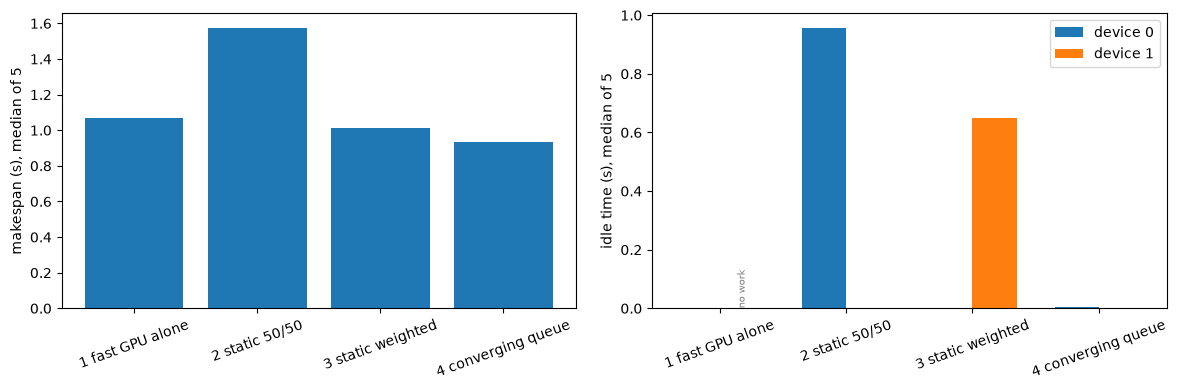

In [6]:
# Idle time is the direct measure of balance: configs 2 and 3 should show a
# clear per-device gap, config 4 should not.
import matplotlib.pyplot as plt

names = list(results)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, [results[n]["median_s"] for n in names])
axes[0].set_ylabel("makespan (s), median of 5")
axes[0].tick_params(axis="x", rotation=20)
width = 0.35
for k, d in enumerate(ranked):
    # idle_s is None when a device was never given work (config 1). That is
    # not zero idle, so it is drawn as a zero-height bar and labelled, never
    # silently averaged in with real measurements.
    raw = [results[n]["per_device"][k]["idle_s"] for n in names]
    xs = np.arange(len(names)) + k * width
    axes[1].bar(xs, [0.0 if v is None else v for v in raw], width,
                label=f"device {d.index}")
    for x, v in zip(xs, raw):
        if v is None:
            axes[1].annotate("no work", (x, 0), rotation=90, fontsize=7,
                             ha="center", va="bottom", color="grey")
axes[1].set_xticks(np.arange(len(names)) + width / 2, names, rotation=20)
axes[1].set_ylabel("idle time (s), median of 5")
axes[1].legend()
plt.tight_layout()
plt.show()

### Host-to-device bandwidth, and why it is measured here

The cell below is part of the same top-to-bottom run as everything above it,
so its execution count continues the sequence rather than restarting. An
earlier revision of this notebook re-measured it on its own to add the PCIe
link-state check, and said so here; that no longer applies.

It is placed after the timed suite deliberately. Both PCIe links park at Gen1
when the host is idle, and a transfer timed from that state folds a
link-training ramp into the number. Running it here means the links have
just been carrying real work, and the generation is sampled across the timed
region so the claim is checked rather than assumed.

In [7]:
# --- Host-to-device transfer per device. --------------------------------
# The A400 sits on PCIe 3.0 x4; torch's static properties cannot see that.
# This measurement is the empirical justification for device_weights.
#
# Both links park at Gen1 after a spell of idleness (link power
# management) -- `nvidia-smi --query-gpu=pcie.link.gen.current` on an
# untouched host reports gen1 for both cards here. A transfer timed from
# that state folds a link-training ramp into the number. The warmups below
# exist to pay that, and the generation is sampled across the timed region
# to prove it was paid rather than assumed: if the link is not at the
# maximum generation the host supports while timing, the figure below is a
# ramp artifact and must not be published as bandwidth.
#
# `before_first_transfer` is read at the top of this cell, not on a cold
# host: in a top-to-bottom run the timed suite above has just finished, so
# the link is legitimately already trained. Seeing gen1 there is fine too --
# what matters is `during_timed_region`.
#
# Only the GENERATION is asserted. Width is physical wiring, not a power
# state: nvidia-smi reports pcie.link.width.max=16 for the A400 because that
# is its connector, while the slot wires x4. The trained link is the truth,
# so the width is read from the timed region rather than from width.max.
SIZE_MB = 256


def _smi(index, fields):
    out = subprocess.run(["nvidia-smi", "-i", str(index), "--format=csv,noheader",
                          f"--query-gpu={fields}"],
                         capture_output=True, text=True).stdout.strip()
    return [f.strip() for f in out.split(",")]


def link_state(index):
    gen, width = _smi(index, "pcie.link.gen.current,pcie.link.width.current")
    return f"gen{gen}x{width}"


# GiB/s per lane, one direction, after 128b/130b (gen3+) / 8b10b encoding.
LANE_GIB_S = {1: 0.233, 2: 0.466, 3: 0.918, 4: 1.833, 5: 3.667}

h2d, links = {}, {}
host = torch.empty(SIZE_MB * 2**20, dtype=torch.uint8, pin_memory=True)
for d in ranked:
    torch.cuda.synchronize(d.index)
    gen_max, gpu_max, host_max = _smi(
        d.index, "pcie.link.gen.max,pcie.link.gen.gpumax,pcie.link.gen.hostmax")
    before = link_state(d.index)
    for _ in range(2):  # warmup: pays the Gen1 -> gen_max link ramp
        host.to(f"cuda:{d.index}", non_blocking=True)
        torch.cuda.synchronize(d.index)
    after_warmup = link_state(d.index)
    times, sampled = [], []
    for _ in range(7):
        torch.cuda.synchronize(d.index)
        t0 = time.perf_counter()
        host.to(f"cuda:{d.index}", non_blocking=True)
        torch.cuda.synchronize(d.index)
        times.append(time.perf_counter() - t0)
        # Sampled between iterations, not inside them: shelling out to
        # nvidia-smi mid-transfer would corrupt the number being timed.
        sampled.append(link_state(d.index))
    gbps = (SIZE_MB / 1024) / np.median(times)
    h2d[d.index] = gbps

    during = sorted(set(sampled))
    steady = len(during) == 1 and during[0].startswith(f"gen{gen_max}x")
    width = int(during[0].split("x")[1])
    ceiling = LANE_GIB_S[int(gen_max)] * width
    links[d.index] = {
        "before_first_transfer": before, "after_warmup": after_warmup,
        "during_timed_region": during, "trained_width": width,
        "gen_max": int(gen_max), "gpu_gen_max": int(gpu_max),
        "host_gen_max": int(host_max),
        "at_gen_max_while_timed": steady,
        "theoretical_gib_s": ceiling, "fraction_of_theoretical": gbps / ceiling,
    }
    print(f"device {d.index} ({d.name}): H2D {gbps:.2f} GiB/s "
          f"(median of 7, {SIZE_MB} MiB pinned)")
    print(f"    link {before} entering this cell -> {after_warmup} after warmup "
          f"-> {'/'.join(during)} across the whole timed region "
          f"(parks at gen1 once the host goes idle)")
    print(f"    gen{gen_max} is the ceiling here (card gen{gpu_max}, host "
          f"gen{host_max}); gen{gen_max}x{width} ~= {ceiling:.2f} GiB/s "
          f"theoretical, measured is {gbps / ceiling:.0%} of it")
    assert steady, (f"device {d.index} link was {during} while timing, not "
                    f"gen{gen_max}: that is a ramp artifact, not bandwidth")

merge_results(h2d_gib_s={str(k): v for k, v in h2d.items()},
              pcie_link={str(k): v for k, v in links.items()})

device 0 (NVIDIA RTX PRO 2000 Blackwell): H2D 6.36 GiB/s (median of 7, 256 MiB pinned)
    link gen3x8 entering this cell -> gen3x8 after warmup -> gen3x8 across the whole timed region (parks at gen1 once the host goes idle)
    gen3 is the ceiling here (card gen5, host gen3); gen3x8 ~= 7.34 GiB/s theoretical, measured is 87% of it


device 1 (NVIDIA RTX A400): H2D 2.83 GiB/s (median of 7, 256 MiB pinned)
    link gen3x4 entering this cell -> gen3x4 after warmup -> gen3x4 across the whole timed region (parks at gen1 once the host goes idle)
    gen3 is the ceiling here (card gen4, host gen3); gen3x4 ~= 3.67 GiB/s theoretical, measured is 77% of it


{'corpus': 'fancyzhx/ag_news train[:8000]',
 'n_texts': 8000,
 'total_tokens': 442423,
 'model': 'sentence-transformers/all-MiniLM-L6-v2',
 'pooling': 'mean',
 'dtype_configured': 'auto',
 'dtype_in_use': ['torch.bfloat16'],
 'max_seq_len': 512,
 'max_batch_tokens': 16384,
 'truncated_inputs': 0,
 'device_budgets': {'0': 16384, '1': 3891},
 'torch': '2.13.0+cu130',
 'torch_cuda': '13.0',
 'torch_arch_list': ['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120'],
 'driver': '610.43.02',
 'devices': [{'index': 0,
   'name': 'NVIDIA RTX PRO 2000 Blackwell',
   'weight': 1.0,
   'capability': [12, 0]},
  {'index': 1,
   'name': 'NVIDIA RTX A400',
   'weight': 0.08823529411764706,
   'capability': [8, 6]}],
 'h2d_gib_s': {'0': np.float64(6.362627089161689),
  '1': np.float64(2.829913590404672)},
 'other_vram_users': '`ollama serve` is running on this host (it always is) but had no model resident at the start of this run: nvidia-smi showed 34 MiB on cuda:0 and 1 MiB on cuda:1, which is dri

## Results

Measured on `fancyzhx/ag_news` train[:8000] — 8,000 texts, 442,423 real
tokens, MiniLM-L6-v2, mean pooling, `dtype=auto` (bfloat16 on both cards),
`max_batch_tokens=16384`, medians of 5 timed runs after 2 discarded warmups.

| # | configuration | makespan | throughput | device 0 idle | device 1 idle |
|---|---|---|---|---|---|
| 1 | fast GPU alone | 1.067 s | 414,799 tok/s | 0.001 s | no work |
| 2 | static 50/50 (by tokens) | 1.577 s | 280,604 tok/s | 0.958 s | 0.001 s |
| 3 | static weighted | 1.012 s | 437,234 tok/s | 0.001 s | 0.650 s |
| 4 | **converging queue** | **0.935 s** | **473,252 tok/s** | 0.004 s | 0.003 s |

- Speedup of **(4) converging queue** over **(1) fast GPU alone**: `1.14x`
- Speedup of **(4)** over **(3) weighted static split**: `1.08x`
- Idle-time gap: config 2 `0.958s` / config 3 `0.650s` vs config 4
  `0.004s` and `0.003s`
- Measured H2D bandwidth ratio between devices: `2.25x` (6.36 vs 2.83 GiB/s)

Read honestly, that is a **modest** win, and it is the real one:

- **Adding a 4 GB A400 to a 16 GB Blackwell buys 14%.** Not 2x. The cards
  are mismatched about 11:1 by static weight, so the ceiling was always low.
  The IQRs do not overlap (config 3 1.006–1.019 s, config 4 0.930–0.938 s),
  so the margin is reproducible rather than noise, but it is 8% over a
  *well-tuned* static split, not a transformation.
- **The scheduler finds capacity the weights do not.** device_weights give
  the A400 8.1% of the work; left to pull, it took **22.4%** (99,106 of
  442,423 tokens, 2,644 items — a third of them). That is why config 3
  leaves it idle for 0.650 s — 64% of its own makespan — while config 4
  idles both devices for under 4 ms. Balance is the claim this notebook
  actually proves.
- **Naive splitting is worse than not using the second GPU at all.** Config
  2 is 1.48x *slower* than one card alone, because an even token split
  hands the slow device half the work and the fast one waits 0.96 s. Note
  this baseline is already the *charitable* version: splitting by token
  count rather than item count, which is what an earlier draft of this
  notebook did and which gave the A400 81% of the tokens.
- **The weights are miscalibrated, and the queue does not care.** H2D
  bandwidth differs by 2.25x while the configured weight ratio is 11.3x.
  Getting that ratio right is exactly the tuning burden the converging
  queue removes.

Correctness was asserted before any of the above was timed: single-device
batching and reassembly bit-identical to one call, sharded float32 within
1.83e-07 (against 1.56e-07 measured between the two cards on identical
input), zero misordered rows and a minimum self-cosine of 0.999974 in the
production bfloat16.

## Machine-readable results

The cell below writes everything above to `dev/output/results.json`, so the
README is filled in by transcription rather than by retyping numbers out of
cell output. Re-run it whenever the timings are re-measured.

In [8]:
# --- Evidence file. README numbers come from here, never from retyping. ---
# Contamination check: this process holds the models, so free VRAM at the end
# is legitimately lower than at the start. What would matter is a THIRD party
# taking memory mid-run, which shows up as a drop far beyond our own models.
vram_end = {i: torch.cuda.mem_get_info(i)[0] for i in VRAM_FREE_AT_START}
for i, start in VRAM_FREE_AT_START.items():
    print(f"cuda:{i} free VRAM {start / 2**30:.2f} GiB at start -> "
          f"{vram_end[i] / 2**30:.2f} GiB at end")

driver = subprocess.run(["nvidia-smi", "--query-gpu=driver_version",
                         "--format=csv,noheader"],
                        capture_output=True, text=True).stdout.strip().splitlines()

payload = {
    "corpus": CORPUS_LABEL,
    "n_texts": len(texts),
    "total_tokens": TOTAL_TOKENS,
    "model": MODEL,
    "pooling": POOLING.value,
    "dtype_configured": DTYPE.value,
    "dtype_in_use": sorted({str(b._dtype) for b in backends}),
    "max_seq_len": MAX_SEQ_LEN,
    "max_batch_tokens": settings.max_batch_tokens,
    "truncated_inputs": sum(b.truncated_count for b in backends),
    "device_budgets": {str(d.index): budgets[d.index] for d in ranked},
    "torch": torch.__version__,
    "torch_cuda": torch.version.cuda,
    "torch_arch_list": torch.cuda.get_arch_list(),
    "driver": driver[0] if driver else None,
    "devices": [{"index": d.index, "name": d.name, "weight": d.weight,
                 "capability": list(torch.cuda.get_device_capability(d.index))}
                for d in ranked],
    "other_vram_users": OTHER_VRAM_USERS,
    "vram_free_start_end_gib": {
        str(i): [VRAM_FREE_AT_START[i] / 2**30, vram_end[i] / 2**30]
        for i in VRAM_FREE_AT_START
    },
    "configs": results,
}
# Merge: h2d_gib_s / pcie_link / correctness_check were written by the cells
# that measured them, and must survive a run of this one.
merge_results(**payload)
print(f"wrote {RESULTS_PATH}  ({RESULTS_PATH.stat().st_size} bytes)")
if CORPUS_LABEL.startswith("!!"):
    print("WARNING: synthetic corpus — these numbers must NOT reach the README.")

cuda:0 free VRAM 15.20 GiB at start -> 13.91 GiB at end
cuda:1 free VRAM 3.58 GiB at start -> 3.02 GiB at end
wrote /home/luxor/Programming/embedx/dev/output/results.json  (5402 bytes)
